# Preparação dos Dados — Tabela Fato Consolidada

**Objetivo:** Limpar, converter e consolidar as tabelas do Olist em uma
tabela fato analítica pronta para a camada dbt e o dashboard Power BI.

**Transformações realizadas:**
- Conversão de colunas de data de string para datetime
- Correção de nomes de colunas com erro de grafia
- Join das tabelas principais em uma visão única por pedido
- Cálculo de métricas derivadas: ticket médio, prazo de entrega, receita total

---

In [4]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

# Caminho relativo ao notebook (dentro de notebooks/)
DATA_RAW = Path('../data/raw')

# Carregamento das tabelas necessárias
orders    = pd.read_csv(DATA_RAW / 'olist_orders_dataset.csv')
items     = pd.read_csv(DATA_RAW / 'olist_order_items_dataset.csv')
payments  = pd.read_csv(DATA_RAW / 'olist_order_payments_dataset.csv')
customers = pd.read_csv(DATA_RAW / 'olist_customers_dataset.csv')
products  = pd.read_csv(DATA_RAW / 'olist_products_dataset.csv')
category  = pd.read_csv(DATA_RAW / 'product_category_name_translation.csv')
reviews   = pd.read_csv(DATA_RAW / 'olist_order_reviews_dataset.csv')

print('Tabelas carregadas com sucesso.')

Tabelas carregadas com sucesso.


## 1. Conversão de Datas e Limpeza

Todas as colunas de data estão como string no dataset original.
Convertemos para datetime para habilitar cálculos de prazo e coorte.

In [5]:
# Colunas de data na tabela orders
colunas_data = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in colunas_data:
    orders[col] = pd.to_datetime(orders[col])

# Filtrar apenas pedidos entregues para análise de receita
orders_entregues = orders[orders['order_status'] == 'delivered'].copy()

print(f"Total de pedidos: {len(orders):,}")
print(f"Pedidos entregues: {len(orders_entregues):,} ({len(orders_entregues)/len(orders)*100:.1f}%)")
print(f"\nTipos após conversão:")
print(orders[colunas_data].dtypes)

Total de pedidos: 99,441
Pedidos entregues: 96,478 (97.0%)

Tipos após conversão:
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


## 2. Consolidação da Tabela Fato

Join das tabelas principais em uma visão única por pedido.
Esta é a base que alimenta todos os KPIs do dashboard.

In [6]:
# Receita total por pedido (agregando pagamentos)
receita_por_pedido = (
    payments
    .groupby('order_id')
    .agg(
        receita_total=('payment_value', 'sum'),
        num_parcelas=('payment_installments', 'max'),
        tipo_pagamento=('payment_type', 'first')
    )
    .reset_index()
)

# Itens por pedido (agregando order_items)
itens_por_pedido = (
    items
    .groupby('order_id')
    .agg(
        num_itens=('order_item_id', 'count'),
        receita_itens=('price', 'sum'),
        frete_total=('freight_value', 'sum')
    )
    .reset_index()
)

# Score médio por pedido
score_por_pedido = (
    reviews
    .groupby('order_id')
    .agg(review_score=('review_score', 'mean'))
    .reset_index()
)

# Join principal
fato = (
    orders_entregues
    .merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
    .merge(receita_por_pedido, on='order_id', how='left')
    .merge(itens_por_pedido, on='order_id', how='left')
    .merge(score_por_pedido, on='order_id', how='left')
)

# Colunas derivadas
fato['prazo_entrega_dias'] = (
    fato['order_delivered_customer_date'] - fato['order_purchase_timestamp']
).dt.days

fato['mes_compra'] = fato['order_purchase_timestamp'].dt.to_period('M')
fato['ano_compra'] = fato['order_purchase_timestamp'].dt.year

print(f"Tabela fato consolidada: {fato.shape[0]:,} pedidos x {fato.shape[1]} colunas")
print(f"\nColunas disponíveis:")
print(list(fato.columns))

Tabela fato consolidada: 96,478 pedidos x 20 colunas

Colunas disponíveis:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_state', 'customer_city', 'receita_total', 'num_parcelas', 'tipo_pagamento', 'num_itens', 'receita_itens', 'frete_total', 'review_score', 'prazo_entrega_dias', 'mes_compra', 'ano_compra']


## 3. Métricas de Negócio — Receita e Ticket Médio

Com a tabela fato consolidada, calculamos os KPIs principais
que vão aparecer no dashboard executivo.

=== KPIs GERAIS — BASE OLIST 2016–2018 ===

Receita total:        R$ 15,422,461.77
Ticket médio:         R$ 159.86
Prazo médio entrega:  12.1 dias
NPS médio (score):    4.16 / 5.0
Total de pedidos:     96,478


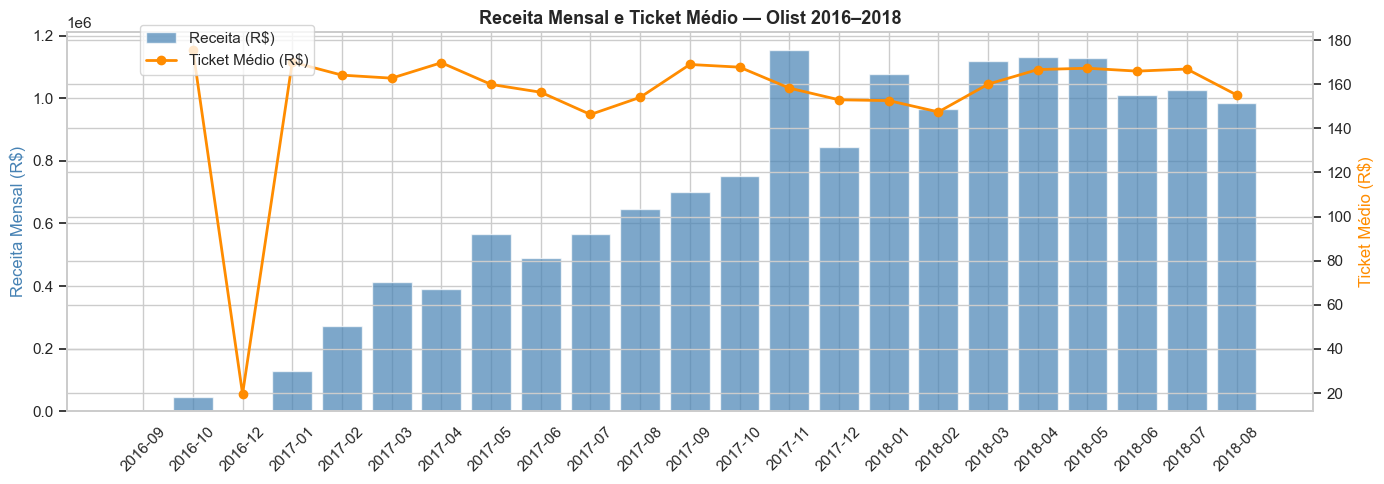

In [8]:
# KPIs gerais
ticket_medio = fato['receita_total'].mean()
receita_total = fato['receita_total'].sum()
prazo_medio = fato['prazo_entrega_dias'].mean()
score_medio = fato['review_score'].mean()

print("=== KPIs GERAIS — BASE OLIST 2016–2018 ===\n")
print(f"Receita total:        R$ {receita_total:,.2f}")
print(f"Ticket médio:         R$ {ticket_medio:,.2f}")
print(f"Prazo médio entrega:  {prazo_medio:.1f} dias")
print(f"NPS médio (score):    {score_medio:.2f} / 5.0")
print(f"Total de pedidos:     {len(fato):,}")

# Receita mensal
receita_mensal = (
    fato.groupby('mes_compra')
    .agg(
        pedidos=('order_id', 'count'),
        receita=('receita_total', 'sum'),
        ticket_medio=('receita_total', 'mean')
    )
    .reset_index()
)
receita_mensal['mes_str'] = receita_mensal['mes_compra'].astype(str)

# Gráfico receita mensal
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(receita_mensal['mes_str'], receita_mensal['receita'],
        color='steelblue', alpha=0.7, label='Receita (R$)')
ax1.set_ylabel('Receita Mensal (R$)', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(receita_mensal['mes_str'], receita_mensal['ticket_medio'],
         color='darkorange', marker='o', linewidth=2, label='Ticket Médio (R$)')
ax2.set_ylabel('Ticket Médio (R$)', color='darkorange')

ax1.set_title('Receita Mensal e Ticket Médio — Olist 2016–2018',
              fontsize=13, fontweight='bold')

fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()

## 4. Receita por Estado

Onde estão os clientes que mais compram?
Concentração geográfica define prioridade de expansão.

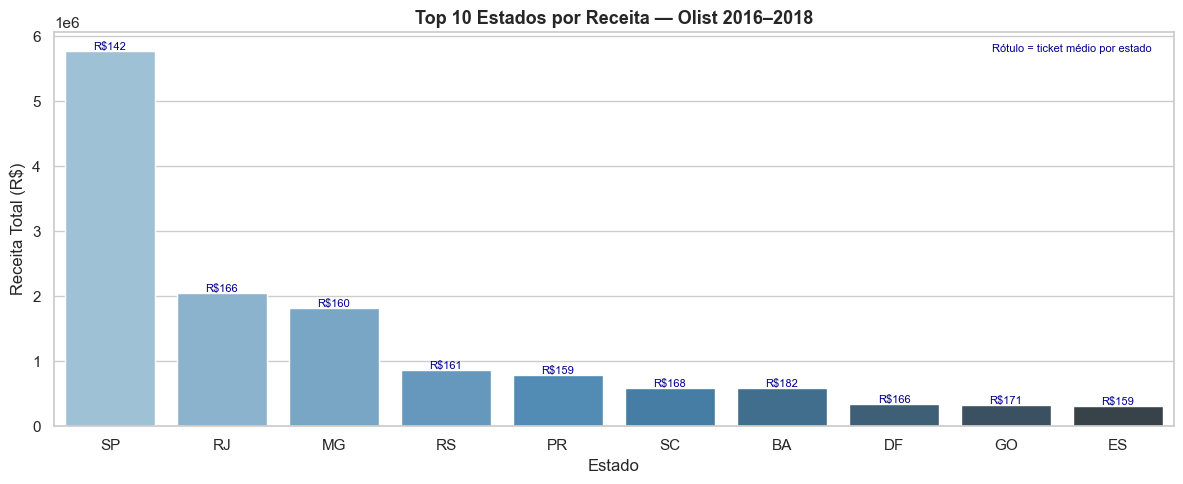

customer_state  pedidos    receita  ticket_medio
            SP    40501 5770266.19    142.475708
            RJ    12350 2055690.45    166.452668
            MG    11354 1819277.61    160.232307
            RS     5345  861802.40    161.235248
            PR     4923  781919.55    158.829890
            SC     3546  595208.40    167.853469
            BA     3256  591270.60    181.594165
            DF     2080  346146.17    166.416428
            GO     1957  334294.22    170.819734
            ES     1995  317682.65    159.239424


In [9]:
# Receita por estado
receita_estado = (
    fato.groupby('customer_state')
    .agg(
        pedidos=('order_id', 'count'),
        receita=('receita_total', 'sum'),
        ticket_medio=('receita_total', 'mean')
    )
    .reset_index()
    .sort_values('receita', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=receita_estado, x='customer_state', y='receita',
            palette='Blues_d', ax=ax)
ax.set_title('Top 10 Estados por Receita — Olist 2016–2018',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Estado')
ax.set_ylabel('Receita Total (R$)')

for i, row in receita_estado.reset_index().iterrows():
    ax.text(i, row['receita'] + 15000,
            f"R${row['ticket_medio']:.0f}", ha='center', fontsize=8, color='darkblue')

ax.text(0.98, 0.95, 'Rótulo = ticket médio por estado',
        transform=ax.transAxes, ha='right', fontsize=8, color='darkblue')

plt.tight_layout()
plt.show()

print(receita_estado[['customer_state','pedidos','receita','ticket_medio']].to_string(index=False))

## 5. Exportação da Tabela Fato

Salvando a tabela fato consolidada para uso na camada dbt + DuckDB.

In [10]:
from pathlib import Path

# Criar pasta gold se não existir
DATA_GOLD = Path('../data/gold')
DATA_GOLD.mkdir(exist_ok=True)

# Exportar tabela fato
output_path = DATA_GOLD / 'fato_pedidos.csv'
fato.to_csv(output_path, index=False)

print(f"Tabela fato exportada: {output_path}")
print(f"Shape: {fato.shape[0]:,} linhas x {fato.shape[1]} colunas")
print(f"Tamanho: {output_path.stat().st_size / 1024**2:.1f} MB")

Tabela fato exportada: ..\data\gold\fato_pedidos.csv
Shape: 96,478 linhas x 20 colunas
Tamanho: 22.0 MB
